In [22]:
import os
import pandas as pd
import numpy as np
import sys
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter
import sys
sys.path.append("/home/jvamaraju/dapt-data-curation/chipgpt/llm_data_collection/") # go to parent dir
from manifest_utils import *

from difflib import SequenceMatcher
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform


In [13]:
def generate_ngrams(path, n):
    parts = path.split(os.path.sep)
    ngrams = [os.path.sep.join(parts[i:i+n]) for i in range(len(parts)-n+1)]
    return ngrams

def analyze_paths_ngrams(data, n=2, min_occurrences=5):
    ngram_counter = Counter()
    paths = data['Path'].unique()

    for path in paths:
        ngrams = generate_ngrams(path, n)
        ngram_counter.update(ngrams)

    common_ngrams = {k: v for k, v in ngram_counter.items() if v >= min_occurrences}
    
    print(f"\nCommon {n}-grams in paths (occurring at least {min_occurrences} times):")
    for ngram, count in sorted(common_ngrams.items(), key=lambda x: x[1], reverse=True):
        print(f"{ngram}: {count} occurrences")


In [20]:
def path_similarity(path1, path2):
    matcher = SequenceMatcher(None, path1, path2)
    return matcher.ratio()

def analyze_paths(data, min_cluster_size=5):
    paths = data['Path'].unique()
    path_count = len(paths)

    similarity_matrix = np.zeros((path_count, path_count))

    for i in range(path_count):
        for j in range(i + 1, path_count):
            similarity = path_similarity(paths[i], paths[j])
            similarity_matrix[i, j] = similarity_matrix[j, i] = 1 - similarity

    clustering = linkage(squareform(similarity_matrix), method='average')
    clusters = fcluster(clustering, t=0.5, criterion='distance')

    unique_clusters = np.unique(clusters)
    print(f"\nCommon patterns in paths (clusters with at least {min_cluster_size} paths):")

    for cluster_id in unique_clusters:
        cluster_indices = np.where(clusters == cluster_id)[0]
        if len(cluster_indices) >= min_cluster_size:
            print(f"\nCluster {cluster_id}:")
            for index in cluster_indices:
                print(f"  {paths[index]}")



In [15]:
# Read the CSV file
# input file should come from command line argument argv[1]
# check number of arguments

input_file = "/home/jvamaraju/dapt-data-curation/chipgpt/llm_data_collection/output_file.csv"

data = pd.read_csv(input_file)

# preprocess
data = manifest_on_open(data)

# Report Percentile of Sizes
print(f"{len(data)} Files")
print(f"Top 10 percentiles (Size_MB):")
print(data['Size_MB'].quantile(q=np.arange(0.9,1.0,0.01)))

print(f"Top 10 files (size):")
for index, row in data.sort_values('Size_MB')[-10:].iterrows():
    print(f"{row['Path']} : {row['Lines']} Lines {row['Size_MB']}MB")


file_size_summary = data.groupby('Extension')['Size_MB'].sum().reset_index().sort_values('Size_MB', ascending=False)

# Round file sizes to the nearest MB
file_size_summary['Size_MB'] = file_size_summary['Size_MB'].apply(round)
# only include if Size_MB > 5
file_size_summary = file_size_summary[file_size_summary['Size_MB'] > 0.01]

# Configure pandas to display all rows
pd.set_option('display.max_rows', None)

# Print the total file size summary
print("File size summary (>5 MB):")
print(file_size_summary.to_string(index=False))


658 Files
Top 10 percentiles (Size_MB):
0.90    0.006823
0.91    0.007273
0.92    0.007894
0.93    0.008299
0.94    0.009308
0.95    0.012531
0.96    0.014888
0.97    0.018241
0.98    0.032202
0.99    0.194506
Name: Size_MB, dtype: float64
Top 10 files (size):
/home/jvamaraju/dapt-data-curation/oh/elink/sw/timeout/DUMP : 5037 Lines 0.19215MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/mailbox/DUMP : 5037 Lines 0.19215MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/mailbox_test/dump : 5112 Lines 0.194506MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/mailbox_test/DUMP : 5112 Lines 0.194506MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/timeout/log : 8192 Lines 0.212992MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/mailbox/log : 8192 Lines 0.212992MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/idelay/log : 8192 Lines 0.212992MB
/home/jvamaraju/dapt-data-curation/oh/elink/sw/mailbox_test/log : 8192 Lines 0.212992MB
/home/jvamaraju/dapt-data-curation/oh/elink/dv/elink_e16_mo

In [16]:
data

,Path,Size,Lines,Extension,Size_MB,Size_KB
0,/home/jvamaraju/dapt-data-curation/oh/LICENSE,1083,21,NO_EXTENSION,0.001083,1.083
1,/home/jvamaraju/dapt-data-curation/oh/emailbox...,7066,219,.V,0.007066,7.066
2,/home/jvamaraju/dapt-data-curation/oh/emailbox...,306,19,.VH,0.000306,0.306
3,/home/jvamaraju/dapt-data-curation/oh/emailbox...,68,1,.MD,0.000068,0.068
4,/home/jvamaraju/dapt-data-curation/oh/emailbox...,1131,28,.EMF,0.001131,1.131
5,/home/jvamaraju/dapt-data-curation/oh/emailbox...,1920,76,.V,0.001920,1.920
6,/home/jvamaraju/dapt-data-curation/oh/padring/...,4381,113,.V,0.004381,4.381
7,/home/jvamaraju/dapt-data-curation/oh/padring/...,4765,180,.V,0.004765,4.765
8,/home/jvamaraju/dapt-data-curation/oh/padring/...,713,23,.V,0.000713,0.713
9,/home/jvamaraju/dapt-data-curation/oh/padring/...,8645,241,.V,0.008645,8.645


In [17]:
file_size_summary

,Extension,Size_MB
27,NO_EXTENSION,2
22,.V,1



File size text-based histogram:
NO_EXTENSION    | ##################################################
.V              | #########################

Histogram of Size_KB for .V, .VH file extension:
0.02 - 0.05     |                                                    (2)
0.05 - 0.14     |                                                    (2)
0.14 - 0.38     | ###                                                (16)
0.38 - 1.01     | ################################################## (221)
1.01 - 2.74     | ##################                                 (83)
2.74 - 7.41     | #############                                      (60)
7.41 - 20.02    | ######                                             (29)
20.02 - 54.12   |                                                    (1)
54.12 - 146.29  |                                                    (0)
146.29 - 395.40 |                                                    (2)

Histogram of Size_KB for .CPP, .HPP, .C, .H file extension:
0.02 - 

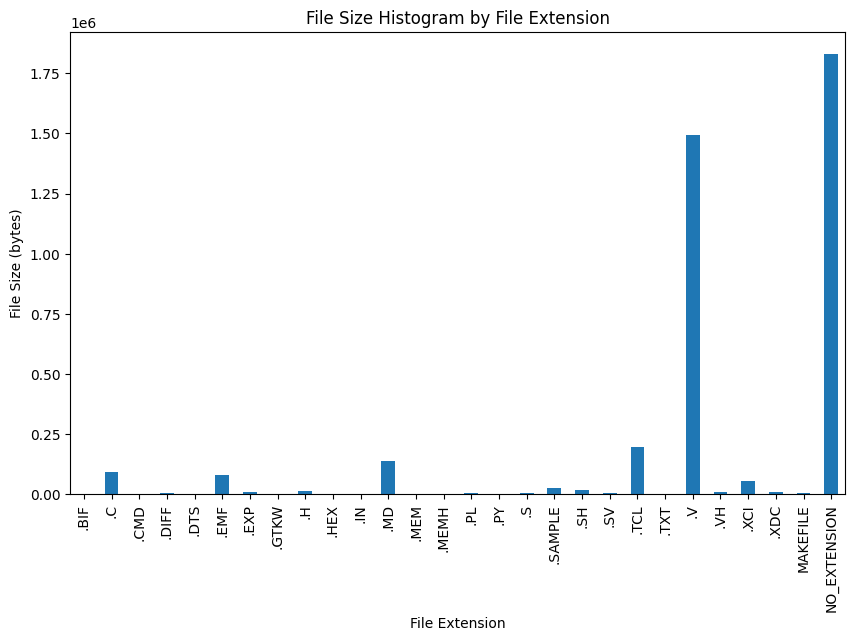

In [23]:

# # Create a text-based histogram for different file types
print("\nFile size text-based histogram:")

max_width = 50
max_value = file_size_summary['Size_MB'].max()

for index, row in file_size_summary.iterrows():
    num_bars = int((row['Size_MB'] / max_value) * max_width)
    print(f"{row['Extension']:<15} | {'#' * num_bars}")

#Create separate text-based histograms for ".V" and ".CPP" file extensions

collection_metrics = ["Size_KB", "Lines"]
file_ext_sets = [[ '.V', '.VH'], [ '.VX', '.VXH'], ['.CPP', '.HPP', '.C', '.H'], ['.SPEC'], ['Makefile', 'Makeppfile']]

for collection_metric in collection_metrics:
    for file_ext_set in file_ext_sets:
        print_histogram(data, file_ext_set, collection_metric, do_log = True)

# try to find commonalities in paths
analyze_paths_ngrams(data, n=2, min_occurrences=100)
analyze_paths_ngrams(data, n=3, min_occurrences=100)
analyze_paths_ngrams(data, n=4, min_occurrences=100)

analyze_paths(data, min_cluster_size=1000)

print("WARNING: TEMPORARILY RUNNING ON A DIFFERENT MANIFEST")

# Create a histogram for different file types
fig, ax = plt.subplots(figsize=(10, 6))
data.groupby('Extension')['Size'].sum().plot(kind='bar', ax=ax)
ax.set_xlabel('File Extension')
ax.set_ylabel('File Size (bytes)')
ax.set_title('File Size Histogram by File Extension')

# Save the histogram to a file
plt.savefig('file_size_histogram.png', bbox_inches='tight')

# Display the histogram
plt.show()
